# Лекция 8. RNN и трансформеры для последовательностей

Демонстрация: простая RNN для классификации текста, self-attention с нуля.

## 1. Простая RNN для sentiment-подобной задачи на игрушечных данных

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)
np.random.seed(0)

vocab = {"good":0,"bad":1,"movie":2,"great":3,"terrible":4,"i":5,"love":6,"hate":7,"this":8,"<pad>":9}
sentences = [
    ("i love this movie", 1), ("great movie", 1), ("i love this", 1),
    ("i hate this movie", 0), ("terrible movie", 0), ("bad movie", 0)
]

def encode(s, maxlen=5):
    ids = [vocab.get(w, 9) for w in s.split()]
    ids = ids[:maxlen] + [9]*(maxlen-len(ids))
    return ids

X = torch.tensor([encode(s) for s,_ in sentences])
y = torch.tensor([l for _,l in sentences], dtype=torch.float32)

class RNNClassifier(nn.Module):
    def __init__(self, vocab_size=10, emb_dim=8, hid=16):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.RNN(emb_dim, hid, batch_first=True)
        self.fc = nn.Linear(hid,1)
    def forward(self,x):
        e = self.emb(x)
        out,h = self.rnn(e)
        return torch.sigmoid(self.fc(h[-1])).squeeze(-1)

rnn_model = RNNClassifier()
opt = torch.optim.Adam(rnn_model.parameters(), lr=0.05)
for epoch in range(200):
    opt.zero_grad()
    out = rnn_model(X)
    loss = F.binary_cross_entropy(out, y)
    loss.backward(); opt.step()
print("RNN финальный loss:", loss.item(), "predictions:", out.detach().numpy().round(2))


RNN финальный loss: 2.8867811124655418e-05 predictions: [1. 1. 1. 0. 0. 0.]


## 2. Self-attention с нуля (для понимания архитектуры Transformer)

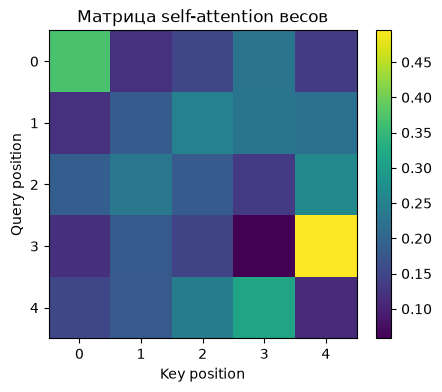

In [2]:

def self_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.transpose(-2,-1) / np.sqrt(d_k)
    weights = F.softmax(scores, dim=-1)
    return weights @ V, weights

torch.manual_seed(1)
seq_len, d = 5, 8
X_seq = torch.randn(1, seq_len, d)
Wq, Wk, Wv = [nn.Linear(d,d) for _ in range(3)]
Q, K, V = Wq(X_seq), Wk(X_seq), Wv(X_seq)
out, attn_weights = self_attention(Q, K, V)

plt.figure(figsize=(5,4))
plt.imshow(attn_weights[0].detach().numpy(), cmap='viridis')
plt.colorbar(); plt.title("Матрица self-attention весов")
plt.xlabel("Key position"); plt.ylabel("Query position")
plt.savefig('output/notebooks/lec8_attention.png', dpi=120)
plt.show()
